In [18]:
train = "/Users/DYNAMIC-COMPUTER/Desktop/PJ-2 Gene Expression Classifier/data_set_ALL_AML_train.csv"
test = "/Users/DYNAMIC-COMPUTER/Desktop/PJ-2 Gene Expression Classifier/data_set_ALL_AML_independent.csv"
class_labels = "/Users/DYNAMIC-COMPUTER/Desktop/PJ-2 Gene Expression Classifier/actual.csv"

In [19]:
import pandas as pd
train_df = pd.read_csv(train, encoding='utf-8')
test_df = pd.read_csv(test, encoding='utf-8')
class_labels_df = pd.read_csv(class_labels, encoding='utf-8')

In [20]:
train_updated = train_df.set_index(train_df.columns[0])
train_updated = train_updated.T
train_updated.reset_index(inplace=True)
train_updated.rename(columns={'index': 'Sample'}, inplace=True)

In [21]:
class_labels_df.rename(columns={"patient": "Sample", "cancer": "Class"}, inplace=True)

In [22]:
train_updated["Sample"] = train_updated["Sample"].astype(str)
class_labels_df["Sample"] = class_labels_df["Sample"].astype(str)

In [23]:
train_final = pd.merge(train_updated, class_labels_df, on='Sample')

As we know, we removed AFFX (Quality Control Probes) for better ML accuracy.

In [24]:
train_updated_without_affx = train_final.loc[:, ~train_final.columns.str.startswith('AFFX-')]

TRAIN TEST SPLIT

In [27]:
X = train_updated_without_affx.drop(columns=['Sample', 'Class']).apply(pd.to_numeric, errors='coerce')
y = train_updated_without_affx['Class']

In [28]:
if X.isnull().values.any():
    print("Genes contained non-numeric text. The Imputer in your pipeline will fix this!")

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

PREPROCESSING

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_threshold", VarianceThreshold(threshold=0.01)),
    ("standard_scaler", StandardScaler()),
    ("select_best", SelectKBest(f_classif, k=10))
])

Logistic Regression

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("log_reg", LogisticRegression(max_iter=500))
])

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

score = cross_val_score(log_reg_pipeline, X, y, cv=skfold)

In [32]:
score

array([0.875, 0.875, 0.875, 1.   , 1.   ])

In [33]:
score.mean()

np.float64(0.925)

In [34]:
rf_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_threshold", VarianceThreshold(threshold=0.01)),
    ("standard_scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))
])

In [35]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf_pipeline = Pipeline([
    ("preprocessing", rf_preprocessing),
    ("rnd_clf", RandomForestClassifier(n_estimators=500, random_state=42))
])

score = cross_val_score(rnd_clf_pipeline, X, y, cv=skfold)

In [36]:
score

array([0.75      , 0.75      , 0.75      , 0.85714286, 0.85714286])

In [37]:
score.mean()

np.float64(0.7928571428571429)

XGB CLASSIFIER

In [38]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('xgb_clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])
y_encoded = y.map({'AML': 0, 'ALL': 1})
score = cross_val_score(xgb_pipeline, X, y_encoded, cv=skfold)

In [39]:
score

array([0.875     , 1.        , 0.875     , 0.85714286, 0.85714286])

In [40]:
score.mean()

np.float64(0.8928571428571429)

DECISION TREE CLASSIFIER

In [41]:
from sklearn.tree import DecisionTreeClassifier
dtree_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('dtree', DecisionTreeClassifier(max_depth=2, random_state=42))
])
score = cross_val_score(dtree_pipeline, X, y, cv=skfold)

In [42]:
score

array([1.        , 1.        , 0.875     , 1.        , 0.71428571])

In [43]:
score.mean()

np.float64(0.9178571428571429)

Logistic Regression has shown the most accruacy at .92

Final Validation Accuracy: 100.00%


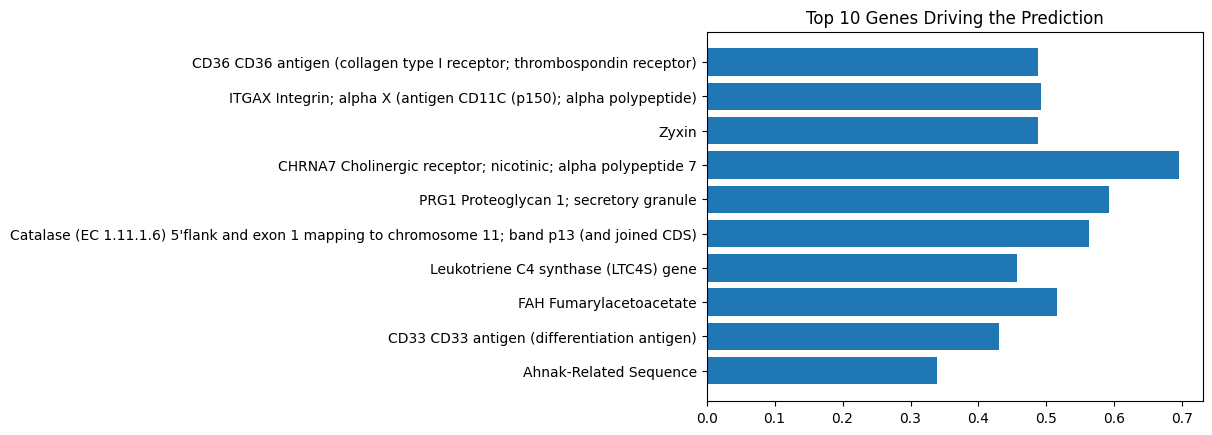

In [45]:
log_reg_pipeline.fit(X_train, y_train)
final_accuracy = log_reg_pipeline.score(X_valid, y_valid)
print(f"Final Validation Accuracy: {final_accuracy * 100:.2f}%")

import matplotlib.pyplot as plt
mask = log_reg_pipeline.named_steps['preprocessing'].named_steps['select_best'].get_support()
gene_names = X.columns[mask]
weights = log_reg_pipeline.named_steps['log_reg'].coef_[0]

plt.barh(gene_names, weights)
plt.title("Top 10 Genes Driving the Prediction")
plt.show()